# Notebook 03 — Clean (Leak-Free) Pipeline

Demonstrates the fold-sealed ML pipeline that avoids all seven leakage types.

**Expected result (null scenario)**: AUROC ≈ 0.48–0.52 for all models.  
Any deviation above 0.55 may indicate residual leakage.

## Fold-Sealed Preprocessing Order
1. Winsorize (1–99th percentile) — fit on **train fold only**
2. StandardScaler — fit on **train fold only**
3. Label threshold (Q1 TCR) — derived from **training fold TCR only**
4. Binarise y_train using fold-derived threshold
5. SMOTE — applied to **training fold only** after binarisation


In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load data and config
df = pd.read_csv('../data/paired_tcr_null_v1_seed2026.csv')

with open('../config/model_config.yaml') as f:
    cfg = yaml.safe_load(f)

print(f"Records: {len(df)}")
print(f"Models configured: {list(cfg.get('models', {}).keys())}")

Records: 1500
Models configured: ['logistic_regression', 'random_forest', 'svm', 'xgboost']


## Run clean pipeline

In [3]:
from src.run_clean_pipeline import nested_cv, build_models, CLEAN_FEATURES

print(f"Clean feature set ({len(CLEAN_FEATURES)} features):")
print(f"  {CLEAN_FEATURES}")
assert 'tg4h' not in CLEAN_FEATURES, "ERROR: tg4h must NOT be in clean features!"
assert 'tcr'  not in CLEAN_FEATURES, "ERROR: tcr must NOT be in clean features!"
print("Feature set integrity: PASS")

Clean feature set (9 features):
  ['age', 'sex', 'bmi', 'hct', 'tp', 'wbv', 'hdl', 'ldl', 'tg0h']
Feature set integrity: PASS


In [4]:
models = build_models(cfg.get('models', {}))
results = {}

for name, model in models.items():
    print(f"Running {name}...", end=' ')
    r = nested_cv(df, name, model, cfg, outer_folds=5, seed=2026)
    results[name] = r
    print(f"AUROC = {r.get('AUROC_mean', 'N/A'):.4f} ± {r.get('AUROC_sd', 0):.4f}")

Running LogisticRegression... 

  CV folds [LogisticRegression]:   0%|                              | 0/5 [00:00<?, ?it/s]

  CV folds [LogisticRegression]:   0%|                    | 0/5 [00:00<?, ?it/s, fold=1/5]

  CV folds [LogisticRegression]:   0%|      | 0/5 [00:00<?, ?it/s, AUROC=0.4952, fold=1/5]

  CV folds [LogisticRegression]:   0%|                    | 0/5 [00:00<?, ?it/s, fold=2/5]

...

  CV folds [XGBoost]:  80%|██████████████████▍    | 4/5 [00:00<00:00,  8.77it/s, fold=5/5]

  CV folds [XGBoost]:  80%|███████▏ | 4/5 [00:00<00:00,  8.77it/s, AUROC=0.5325, fold=5/5]

  CV folds [XGBoost]: 100%|█████████| 5/5 [00:00<00:00,  9.05it/s, AUROC=0.5325, fold=5/5]

  CV folds [XGBoost]: 100%|█████████| 5/5 [00:00<00:00,  8.37it/s, AUROC=0.5325, fold=5/5]

AUROC = 0.4822 ± 0.0318


## Results summary

In [5]:
rows = []
for name, r in results.items():
    rows.append({
        'Model': name,
        'AUROC': f"{r['AUROC_mean']:.4f} ± {r['AUROC_sd']:.4f}",
        'PR-AUC': f"{r['PR_AUC_mean']:.4f} ± {r['PR_AUC_sd']:.4f}",
        'Brier': f"{r['Brier_mean']:.4f} ± {r['Brier_sd']:.4f}",
    })
summary = pd.DataFrame(rows)
print("Clean Pipeline Results — Null Scenario (seed 2026)")
print("Expected AUROC: ≈ 0.48–0.52 (random noise baseline)")
print()
print(summary.to_string(index=False))

Clean Pipeline Results — Null Scenario (seed 2026)
Expected AUROC: ≈ 0.48–0.52 (random noise baseline)

             Model           AUROC          PR-AUC           Brier
LogisticRegression 0.5090 ± 0.0164 0.2762 ± 0.0224 0.2517 ± 0.0034
      RandomForest 0.4934 ± 0.0328 0.2664 ± 0.0271 0.2339 ± 0.0053
               SVM 0.4986 ± 0.0293 0.2691 ± 0.0305 0.2566 ± 0.0140
           XGBoost 0.4822 ± 0.0318 0.2604 ± 0.0130 0.2534 ± 0.0090


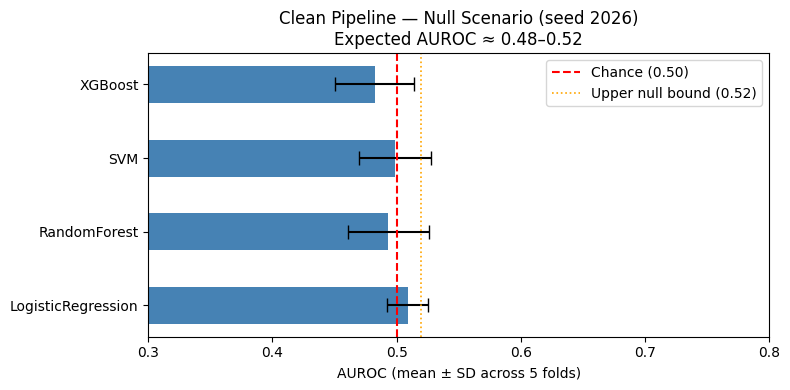

In [6]:
# AUROC bar plot
names = list(results.keys())
aurocs = [results[n]['AUROC_mean'] for n in names]
errors = [results[n]['AUROC_sd'] for n in names]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(names, aurocs, xerr=errors, color='steelblue', capsize=5, height=0.5)
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, label='Chance (0.50)')
ax.axvline(0.52, color='orange', linestyle=':', linewidth=1.2, label='Upper null bound (0.52)')
ax.set_xlabel('AUROC (mean ± SD across 5 folds)')
ax.set_title('Clean Pipeline — Null Scenario (seed 2026)\nExpected AUROC ≈ 0.48–0.52')
ax.set_xlim(0.3, 0.8)
ax.legend()
plt.tight_layout()
plt.savefig('../results/figures/03_clean_pipeline_auroc.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Save results CSV
import pandas as pd
rows_csv = []
for name, r in results.items():
    rows_csv.append({
        'model': name, 'pipeline': 'clean',
        'AUROC_mean': r['AUROC_mean'], 'AUROC_sd': r['AUROC_sd'],
        'PR_AUC_mean': r['PR_AUC_mean'], 'PR_AUC_sd': r['PR_AUC_sd'],
        'Brier_mean': r['Brier_mean'], 'Brier_sd': r['Brier_sd'],
    })
pd.DataFrame(rows_csv).to_csv('../results/tables/clean_results.csv', index=False)
print("Saved: results/tables/clean_results.csv")

Saved: results/tables/clean_results.csv
